# Práctica: Índice Inverso, Lematización, Bolsas de Palabras y LSH
**Datos Masivos I**

## 1. Importaciones y Configuración

In [3]:
import math
import time
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from sklearn.datasets import fetch_20newsgroups
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize

nltk.download('punkt',                      quiet=True)
nltk.download('punkt_tab',                  quiet=True)
nltk.download('wordnet',                    quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('omw-1.4',                    quiet=True)
lemmatizer = WordNetLemmatizer()

## 2. Carga de Datos – 20 Newsgroups

In [5]:
newsgroups_raw   = fetch_20newsgroups(subset='train')
newsgroups_clean = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))

orig       = newsgroups_clean.data
etiquetas  = newsgroups_raw.target       # índice de categoría por documento
categorias = newsgroups_raw.target_names

print(f'Documentos cargados : {len(orig)}')
print(f'Categorías          : {len(categorias)}')
for cat in categorias:
    print(f'  - {cat}')

Documentos cargados : 11314
Categorías          : 20
  - alt.atheism
  - comp.graphics
  - comp.os.ms-windows.misc
  - comp.sys.ibm.pc.hardware
  - comp.sys.mac.hardware
  - comp.windows.x
  - misc.forsale
  - rec.autos
  - rec.motorcycles
  - rec.sport.baseball
  - rec.sport.hockey
  - sci.crypt
  - sci.electronics
  - sci.med
  - sci.space
  - soc.religion.christian
  - talk.politics.guns
  - talk.politics.mideast
  - talk.politics.misc
  - talk.religion.misc


In [6]:
idx = 0
print(f'Categoría : {categorias[etiquetas[idx]]}')
print(f'Texto     :\n{orig[idx][:500]}...')

Categoría : rec.autos
Texto     :
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


## 3. Stopwords

In [8]:
with open("datitos.txt", 'r', encoding='utf-8') as f:
    datitos = {line.strip() for line in f if line.strip()}

print(f'Stopwords cargadas: {len(datitos)}')
print(f'Ejemplo            : {list(datitos)[:10]}')

Stopwords cargadas: 570
Ejemplo            : ['currently', 'or', 'hopefully', 'com', 'am', "there's", 'greetings', 'gone', "doesn't", 'whoever']


## 4. Preprocesamiento de Texto

El pipeline de limpieza aplica los siguientes pasos a cada documento:
1. Tokenización y conversión a minúsculas
2. Filtrado de tokens no alfabéticos
3. **POS tagging en batch** (una sola llamada por documento)
4. Lematización guiada por la etiqueta gramatical
5. Eliminación de stopwords

In [11]:
def get_wordnet_pos(tag):
    """Convierte etiqueta Penn Treebank al formato de WordNet."""
    tag_dict = {'J': wordnet.ADJ, 'N': wordnet.NOUN, 'V': wordnet.VERB, 'R': wordnet.ADV}
    return tag_dict.get(tag[0].upper(), wordnet.NOUN)


def lematizar(texto):
    if not texto:
        return ''
    tokens = [w for w in word_tokenize(texto.lower()) if w.isalpha()]
    # pos_tag recibe todos los tokens de golpe (mucho más rápido que uno por uno)
    lemas = [lemmatizer.lemmatize(w, get_wordnet_pos(pos)) for w, pos in nltk.pos_tag(tokens)]
    return ' '.join(lemas)


def mochar(texto, stopwords):
    return [w for w in texto.split() if w not in stopwords]

In [12]:
texto_ejemplo = 'The dogs were running quickly in different NASA missions. Studies were changing rapidly!'
lematizado    = lematizar(texto_ejemplo)
filtrado      = mochar(lematizado, datitos)

print(f'Original  : {texto_ejemplo}')
print(f'Lematizado: {lematizado}')
print(f'Filtrado  : {filtrado}')

Original  : The dogs were running quickly in different NASA missions. Studies were changing rapidly!
Lematizado: the dog be run quickly in different nasa mission study be change rapidly
Filtrado  : ['dog', 'run', 'quickly', 'nasa', 'mission', 'study', 'change', 'rapidly']


## 5. Construcción del Corpus Limpio

In [14]:
procesados = []
vacios = 0
for texto in orig:
    tokens = mochar(lematizar(texto), datitos)
    if tokens:
        procesados.append(' '.join(tokens))
    else:
        vacios += 1
print(f'Documentos procesados         : {len(procesados)}')
print(f'Documentos vacíos descartados : {vacios}')

Documentos procesados         : 10976
Documentos vacíos descartados : 338


## 6. Frecuencias del Corpus

Se calculan dos métricas por término:
- **freq_total**: cuántas veces aparece en todo el corpus
- **freq_documental**: en cuántos documentos distintos aparece

In [17]:
def calcular_frecuencias(documentos):
    freq_total      = defaultdict(int)
    freq_documental = defaultdict(int)
    for doc in documentos:
        palabras = doc.split()
        for p in palabras:
            freq_total[p] += 1
        for p in set(palabras):
            freq_documental[p] += 1
    return dict(freq_total), dict(freq_documental)
freq_total, freq_documental = calcular_frecuencias(procesados)
TOP_N        = 5000
palabras_max = sorted(freq_total, key=freq_total.get, reverse=True)[:TOP_N]
print(f'Vocabulario total   : {len(freq_total):,} palabras únicas')
print(f'Vocabulario reducido: {TOP_N:,} palabras (top por frecuencia)')
print(f'{"Palabra":<20} {"Freq. total":>12} {"Freq. doc.":>12}')
print('-' * 46)
for p in palabras_max[:10]:
    print(f'{p:<20} {freq_total[p]:>12,} {freq_documental[p]:>12,}')

Vocabulario total   : 53,218 palabras únicas
Vocabulario reducido: 5,000 palabras (top por frecuencia)
Palabra               Freq. total   Freq. doc.
----------------------------------------------
max                         4,550           72
make                        4,185        2,355
people                      4,122        1,824
time                        3,488        1,977
good                        3,293        1,982
work                        2,833        1,607
year                        2,643        1,421
system                      2,595        1,099
file                        2,561          627
problem                     2,305        1,356


## 7. Bolsas de Palabras

Cada documento se representa como una lista dispersa de pares `(palabra, frecuencia)`,
incluyendo únicamente los términos que pertenecen al vocabulario reducido y que aparecen en el documento.

In [20]:
def calcular_bolsas(documentos, freq_total, n=5000):
    vocab = set(sorted(freq_total, key=freq_total.get, reverse=True)[:n])
    resultado = []
    for doc in documentos:
        conteo = Counter(doc.split())
        bolsa  = [(p, c) for p, c in conteo.items() if p in vocab]
        resultado.append(bolsa)
    return resultado
conteodocs = calcular_bolsas(procesados, freq_total)
print(f'Bolsas generadas: {len(conteodocs)}')
print(f'Ejemplo – doc 0 (top 8 términos por frecuencia):')
print(sorted(conteodocs[0], key=lambda x: x[1], reverse=True)[:8])

Bolsas generadas: 10976
Ejemplo – doc 0 (top 8 términos por frecuencia):
[('car', 4), ('day', 1), ('sport', 1), ('late', 1), ('early', 1), ('call', 1), ('door', 1), ('small', 1)]


## 8. Vocabulario

Se construye el vocabulario formal asignando a cada palabra un **ID numérico** y su valor **IDF**:

$$idf(t) = \log\!\left(\frac{N}{df(t)}\right)$$

donde $N$ es el total de documentos y $df(t)$ es cuántos documentos contienen el término $t$.

In [23]:
N = len(procesados)
vocab_idx   = {p: i for i, p in enumerate(palabras_max)}   
vocabulario = {
    p: {
        'id':         i,
        'freq_total': freq_total[p],
        'freq_doc':   freq_documental[p],
        'idf':        math.log(N / freq_documental[p])
    }
    for i, p in enumerate(palabras_max)
}
print(f'Tamaño del vocabulario: {len(vocabulario):,} términos')
print(f'{"Palabra":<20} {"ID":>6} {"Freq.Total":>11} {"Freq.Doc":>10} {"IDF":>8}')
print('-' * 60)
for p in palabras_max[:10]:
    v = vocabulario[p]
    print(f'{p:<20} {v["id"]:>6} {v["freq_total"]:>11,} {v["freq_doc"]:>10,} {v["idf"]:>8.4f}')

Tamaño del vocabulario: 5,000 términos
Palabra                  ID  Freq.Total   Freq.Doc      IDF
------------------------------------------------------------
max                       0       4,550         72   5.0268
make                      1       4,185      2,355   1.5392
people                    2       4,122      1,824   1.7947
time                      3       3,488      1,977   1.7141
good                      4       3,293      1,982   1.7116
work                      5       2,833      1,607   1.9213
year                      6       2,643      1,421   2.0444
system                    7       2,595      1,099   2.3013
file                      8       2,561        627   2.8625
problem                   9       2,305      1,356   2.0912


## 9. Representación Vectorial

Cada bolsa de palabras se convierte en un vector de dimensión fija (= tamaño del vocabulario).

- **Vector de conteos**: la posición $i$ contiene $tf(t_i, d)$
- **Vector TF-IDF**: la posición $i$ contiene $tf(t_i, d) \times idf(t_i)$

Se pre-normaliza la matriz TF-IDF (norma $L_2 = 1$) para que la similitud coseno sea un simple producto punto.

In [26]:
def bolsa_a_vector_conteo(bolsa, vocab_idx):
    v = np.zeros(len(vocab_idx), dtype=np.float32)
    for p, c in bolsa:
        if p in vocab_idx:
            v[vocab_idx[p]] = c
    return v
def bolsa_a_vector_tfidf(bolsa, vocab_idx, vocabulario):
    v = np.zeros(len(vocab_idx), dtype=np.float32)
    for p, c in bolsa:
        if p in vocab_idx:
            v[vocab_idx[p]] = c * vocabulario[p]['idf']
    return v

In [27]:
i, j = 0, 1
v0_tfidf = bolsa_a_vector_tfidf(conteodocs[i], vocab_idx, vocabulario)
v0_cont  = bolsa_a_vector_conteo(conteodocs[i], vocab_idx)
print(f'Doc {i} – categoría: {categorias[etiquetas[i]]}')
print(f'  Entradas no-cero en vector TF-IDF : {np.count_nonzero(v0_tfidf)}')
print(f'  Entradas no-cero en vector conteo : {np.count_nonzero(v0_cont)}')
print(f'  Norma TF-IDF                      : {np.linalg.norm(v0_tfidf):.4f}')

Doc 0 – categoría: rec.autos
  Entradas no-cero en vector TF-IDF : 22
  Entradas no-cero en vector conteo : 22
  Norma TF-IDF                      : 21.5858


## 10. Medidas de Similitud

Se implementan tres medidas para comparar documentos:

| Medida | Fórmula | Opera sobre |
|--------|---------|-------------|
| **Coseno** | $\cos(x,y)=\frac{x\cdot y}{\|x\|\|y\|}$ | Vectores TF-IDF |
| **Jaccard** | $J(A,B)=\frac{card(A\cap B)}{card(A\cup B)}$ | Conjuntos de palabras |
| **MinMax** | $S(x,y)=\frac{\sum_i\min(x_i,y_i)}{\sum_i\max(x_i,y_i)}$ | Vectores de conteos |

In [30]:
def similitud_coseno(v1, v2):
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    return float(np.dot(v1, v2) / denom) if denom > 0 else 0.0
def similitud_jaccard(bolsa1, bolsa2):
    s1    = {p for p, _ in bolsa1}
    s2    = {p for p, _ in bolsa2}
    inter = len(s1 & s2)
    union = len(s1 | s2)
    return inter / union if union > 0 else 0.0
def similitud_minmax(v1, v2):
    num = float(np.sum(np.minimum(v1, v2)))
    den = float(np.sum(np.maximum(v1, v2)))
    return num / den if den > 0 else 0.0

## 11. Comparación Directa de Documentos

In [32]:
i, j = 0, 1
b1, b2   = conteodocs[i], conteodocs[j]
v1_tf    = bolsa_a_vector_tfidf(b1, vocab_idx, vocabulario)
v2_tf    = bolsa_a_vector_tfidf(b2, vocab_idx, vocabulario)
v1_cont  = bolsa_a_vector_conteo(b1, vocab_idx)
v2_cont  = bolsa_a_vector_conteo(b2, vocab_idx)
print(f'Doc {i} → {categorias[etiquetas[i]]}')
print(f'Doc {j} → {categorias[etiquetas[j]]}')
print(f'Coseno  (TF-IDF) : {similitud_coseno(v1_tf,   v2_tf):.4f}')
print(f'Jaccard          : {similitud_jaccard(b1, b2):.4f}')
print(f'MinMax  (conteo) : {similitud_minmax(v1_cont, v2_cont):.4f}')

Doc 0 → rec.autos
Doc 1 → comp.sys.mac.hardware
Coseno  (TF-IDF) : 0.0185
Jaccard          : 0.0175
MinMax  (conteo) : 0.0147


## 12. Búsqueda por Fuerza Bruta

La búsqueda por fuerza bruta compara la consulta contra **todos** los documentos del corpus.

Dado que `tfidf_norm` ya está pre-normalizada, el coseno se reduce a un producto matricial:

$$\text{sims} = \mathbf{M}_{\text{norm}} \cdot \hat{q}$$

In [35]:
def busqueda_fuerza_bruta(consulta_bolsa, tfidf_norm, vocab_idx, vocabulario,
                          top_k=5, excluir_idx=None):
    v_q = bolsa_a_vector_tfidf(consulta_bolsa, vocab_idx, vocabulario)
    norm_q = np.linalg.norm(v_q)
    if norm_q == 0:
        return []
    v_q_norm = (v_q / norm_q).astype(np.float32)
    sims = tfidf_norm @ v_q_norm
    if excluir_idx is not None:
        sims[excluir_idx] = -1.0
    top_idx = np.argsort(sims)[::-1][:top_k]
    return [(int(i), float(sims[i])) for i in top_idx]

In [36]:
tfidf_matrix = np.zeros((len(conteodocs), len(vocab_idx)), dtype=np.float32)
for i, bolsa in enumerate(conteodocs):
    for p, c in bolsa:
        if p in vocab_idx:
            tfidf_matrix[i, vocab_idx[p]] = c * vocabulario[p]['idf']
norms = np.linalg.norm(tfidf_matrix, axis=1, keepdims=True)
norms[norms == 0] = 1
tfidf_norm = (tfidf_matrix / norms).astype(np.float32)

In [37]:
idx_consulta = 42
resultados_fb = busqueda_fuerza_bruta(
    conteodocs[idx_consulta], tfidf_norm, vocab_idx, vocabulario,
    excluir_idx=idx_consulta
)
print(f'Consulta (doc {idx_consulta}) – {categorias[etiquetas[idx_consulta]]}')
print(f'Texto   : {orig[idx_consulta][:300]}...')
print('Top 5 documentos más similares:')
for rank, (doc_id, sim) in enumerate(resultados_fb, 1):
    print(f'  {rank}. doc {doc_id:>5} | sim={sim:.4f} | {categorias[etiquetas[doc_id]]}')
mejor_id, mejor_sim = resultados_fb[0]
print(f'Documento recuperado (doc {mejor_id}):')
print(orig[mejor_id][:400] + '...')

Consulta (doc 42) – comp.sys.ibm.pc.hardware
Texto   : Western Digital 1-800-832-4778.....Sam...
Top 5 documentos más similares:
  1. doc   647 | sim=0.3545 | alt.atheism
  2. doc  8899 | sim=0.3537 | sci.med
  3. doc  7213 | sim=0.3537 | sci.med
  4. doc  3254 | sim=0.3232 | comp.graphics
  5. doc 10470 | sim=0.3146 | talk.politics.guns
Documento recuperado (doc 647):

 











Sure. Yes, I did. You see I don't think that rape and murder should
be dealt with lightly. You, being so interested in leniency for
leniency's sake, apparently think that people should simply be
told the "did a _bad_ thing."



Misjudgments should be avoided as much as possible.
I suspect that it's pretty unlikely that, given my requirement
of repeated offenses, that misjudgments are...


In [38]:
def procesar_consulta(texto, datitos, vocab_idx):
    tokens = mochar(lematizar(texto), datitos)
    conteo = Counter(tokens)
    return [(p, c) for p, c in conteo.items() if p in vocab_idx]
consultas = [
    'nasa space mission satellite',
    'government crime enforcement security',
    'computer graphics image rendering',
]
print('=== Búsqueda por fuerza bruta – consultas textuales ===')
for consulta in consultas:
    bolsa_q   = procesar_consulta(consulta, datitos, vocab_idx)
    resultados = busqueda_fuerza_bruta(bolsa_q, tfidf_norm, vocab_idx, vocabulario)
    print(f'\nConsulta: "{consulta}"')
    for rank, (doc_id, sim) in enumerate(resultados, 1):
        print(f'  {rank}. doc {doc_id:>5} | sim={sim:.4f} | {categorias[etiquetas[doc_id]]}')

=== Búsqueda por fuerza bruta – consultas textuales ===

Consulta: "nasa space mission satellite"
  1. doc  4686 | sim=0.4537 | sci.crypt
  2. doc  4281 | sim=0.4410 | rec.motorcycles
  3. doc  8820 | sim=0.4186 | comp.sys.mac.hardware
  4. doc  5704 | sim=0.4161 | comp.graphics
  5. doc  5789 | sim=0.4037 | alt.atheism

Consulta: "government crime enforcement security"
  1. doc   719 | sim=0.3192 | soc.religion.christian
  2. doc   250 | sim=0.3159 | talk.politics.misc
  3. doc  2006 | sim=0.3029 | talk.politics.misc
  4. doc  7554 | sim=0.2813 | sci.space
  5. doc 10116 | sim=0.2681 | comp.graphics

Consulta: "computer graphics image rendering"
  1. doc  5264 | sim=0.5268 | soc.religion.christian
  2. doc  3634 | sim=0.5090 | soc.religion.christian
  3. doc  2819 | sim=0.4843 | comp.os.ms-windows.misc
  4. doc  6013 | sim=0.4549 | talk.religion.misc
  5. doc  4029 | sim=0.4304 | comp.windows.x


## 13. Índice Inverso

El índice inverso invierte la relación documento → palabras:

$$\text{palabra} \longrightarrow [\text{doc}_1,\ \text{doc}_2,\ \ldots]$$

Esto permite encontrar documentos candidatos sin recorrer todo el corpus.

In [41]:
def construir_indice_inverso(conteodocs):
    indice = defaultdict(list)
    for doc_id, bolsa in enumerate(conteodocs):
        for palabra, _ in bolsa:
            indice[palabra].append(doc_id)
    return dict(indice)
indice_inverso = construir_indice_inverso(conteodocs)
palabra_ej = palabras_max[50]
docs_ej    = indice_inverso[palabra_ej]
print(f'\nEjemplo → "{palabra_ej}" aparece en {len(docs_ej):,} documentos')
print(f'Primeros 10 doc_ids: {docs_ej[:10]}')


Ejemplo → "lot" aparece en 824 documentos
Primeros 10 doc_ids: [28, 50, 78, 92, 100, 104, 105, 115, 153, 161]


## 14. Búsqueda Acelerada con Índice Inverso

Flujo de búsqueda acelerada:

1. Consulta → índice inverso → **documentos candidatos** (unión de posting lists)
2. Calcular similitud **solo** contra candidatos
3. Ordenar y devolver top-k

Se evita calcular similitud contra documentos que no comparten ningún término con la consulta.

In [44]:
def busqueda_indice_inverso(consulta_bolsa, indice, tfidf_norm, vocab_idx, vocabulario, top_k=5):
    candidatos = set()
    for p, _ in consulta_bolsa:
        if p in indice:
            candidatos.update(indice[p])
    candidatos = list(candidatos)
    if not candidatos:
        return [], 0
    v_q = bolsa_a_vector_tfidf(consulta_bolsa, vocab_idx, vocabulario)
    norm_q = np.linalg.norm(v_q)
    if norm_q == 0:
        return [], len(candidatos)
    v_q_norm = (v_q / norm_q).astype(np.float32)
    sims      = tfidf_norm[candidatos] @ v_q_norm
    top_local = np.argsort(sims)[::-1][:top_k]
    return [(candidatos[k], float(sims[k])) for k in top_local], len(candidatos)

In [45]:
print('=== Búsqueda con índice inverso – mismas consultas ===')
for consulta in consultas:
    bolsa_q             = procesar_consulta(consulta, datitos, vocab_idx)
    resultados, n_cand  = busqueda_indice_inverso(
        bolsa_q, indice_inverso, tfidf_norm, vocab_idx, vocabulario
    )
    pct = n_cand / len(conteodocs) * 100
    print(f'\nConsulta: "{consulta}"')
    print(f'Candidatos revisados: {n_cand:,} / {len(conteodocs):,} ({pct:.1f}%)')
    for rank, (doc_id, sim) in enumerate(resultados, 1):
        print(f'  {rank}. doc {doc_id:>5} | sim={sim:.4f} | {categorias[etiquetas[doc_id]]}')

=== Búsqueda con índice inverso – mismas consultas ===

Consulta: "nasa space mission satellite"
Candidatos revisados: 502 / 10,976 (4.6%)
  1. doc  4686 | sim=0.4537 | sci.crypt
  2. doc  4281 | sim=0.4410 | rec.motorcycles
  3. doc  8820 | sim=0.4186 | comp.sys.mac.hardware
  4. doc  5704 | sim=0.4161 | comp.graphics
  5. doc  5789 | sim=0.4037 | alt.atheism

Consulta: "government crime enforcement security"
Candidatos revisados: 824 / 10,976 (7.5%)
  1. doc   719 | sim=0.3192 | soc.religion.christian
  2. doc   250 | sim=0.3159 | talk.politics.misc
  3. doc  2006 | sim=0.3029 | talk.politics.misc
  4. doc  7554 | sim=0.2813 | sci.space
  5. doc 10116 | sim=0.2681 | comp.graphics

Consulta: "computer graphics image rendering"
Candidatos revisados: 900 / 10,976 (8.2%)
  1. doc  5264 | sim=0.5268 | soc.religion.christian
  2. doc  3634 | sim=0.5090 | soc.religion.christian
  3. doc  2819 | sim=0.4843 | comp.os.ms-windows.misc
  4. doc  6013 | sim=0.4549 | talk.religion.misc
  5. doc  4

## 15. Comparación: Fuerza Bruta vs Índice Inverso

In [47]:
stats = []
for consulta in consultas:
    bolsa_q = procesar_consulta(consulta, datitos, vocab_idx)

    t0     = time.time()
    res_fb = busqueda_fuerza_bruta(bolsa_q, tfidf_norm, vocab_idx, vocabulario)
    t_fb   = time.time() - t0

    t0             = time.time()
    res_ii, n_cand = busqueda_indice_inverso(
        bolsa_q, indice_inverso, tfidf_norm, vocab_idx, vocabulario
    )
    t_ii = time.time() - t0

    top_fb = res_fb[0][0] if res_fb else None
    top_ii = res_ii[0][0] if res_ii else None

    stats.append({
        'consulta': consulta, 't_fb': t_fb, 't_ii': t_ii,
        'cand_fb': len(conteodocs), 'cand_ii': n_cand,
        'mismo_top': top_fb == top_ii
    })
col = f'{"Consulta":<38} {"T.FB(s)":>8} {"T.II(s)":>8} {"Docs FB":>8} {"Cands II":>9} {"=Top?":>6}'
print(col)
print('-' * len(col))
for s in stats:
    print(f'{s["consulta"]:<38} {s["t_fb"]:>8.4f} {s["t_ii"]:>8.4f} '
          f'{s["cand_fb"]:>8,} {s["cand_ii"]:>9,} {str(s["mismo_top"]):>6}')

Consulta                                T.FB(s)  T.II(s)  Docs FB  Cands II  =Top?
----------------------------------------------------------------------------------
nasa space mission satellite             0.0173   0.0083   10,976       502   True
government crime enforcement security    0.0163   0.0164   10,976       824   True
computer graphics image rendering        0.0191   0.0125   10,976       900   True


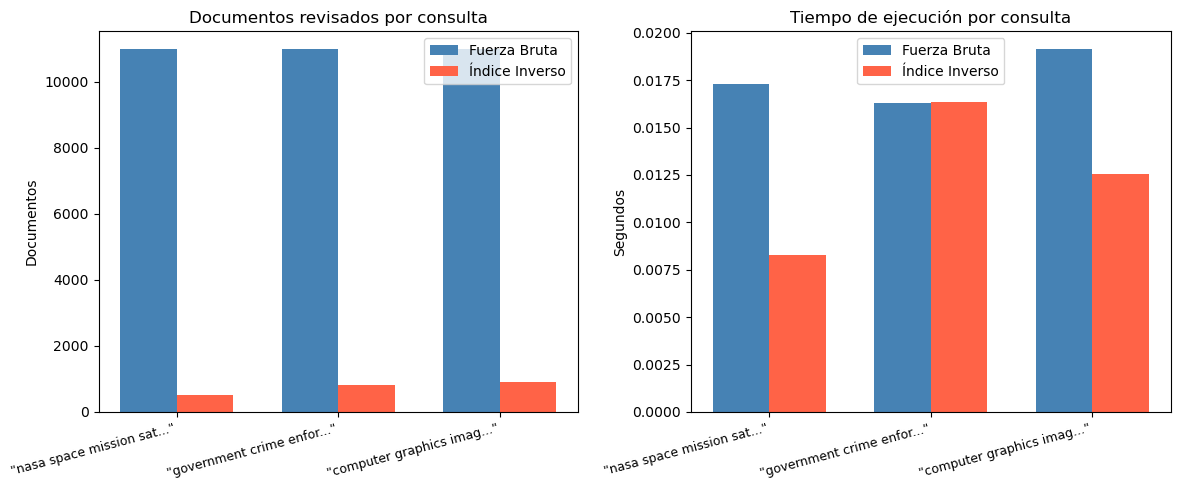

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels   = [f'"{c[:22]}..."' if len(c) > 22 else f'"{c}"' for c in consultas]
cand_fb  = [s['cand_fb'] for s in stats]
cand_ii  = [s['cand_ii'] for s in stats]
t_fb_lst = [s['t_fb']    for s in stats]
t_ii_lst = [s['t_ii']    for s in stats]
x, w     = range(len(consultas)), 0.35
ax = axes[0]
ax.bar([i - w/2 for i in x], cand_fb, w, label='Fuerza Bruta', color='steelblue')
ax.bar([i + w/2 for i in x], cand_ii, w, label='Índice Inverso', color='tomato')
ax.set_title('Documentos revisados por consulta')
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Documentos')
ax.legend()
ax = axes[1]
ax.bar([i - w/2 for i in x], t_fb_lst, w, label='Fuerza Bruta', color='steelblue')
ax.bar([i + w/2 for i in x], t_ii_lst, w, label='Índice Inverso', color='tomato')
ax.set_title('Tiempo de ejecución por consulta')
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Segundos')
ax.legend()
plt.tight_layout()
plt.show()

---
# Parte 2: Implementación de LSH
**Locality-Sensitive Hashing con los mismos documentos procesados**

El objetivo de esta parte es construir funciones hash que agrupen documentos similares en
**buckets** y generen **pares candidatos**, sin comparar cada documento contra todos los demás.

Se usa **MinHash** para estimar similitud Jaccard y el esquema de **banding** para reducir
el espacio de búsqueda. Finalmente se compara LSH contra la búsqueda exacta midiendo:

| Símbolo | Significado |
|---------|-------------|
| **VP** | Candidato LSH y realmente similar |
| **FP** | Candidato LSH pero NO realmente similar |
| **FN** | No candidato pero realmente similar |
| **VN** | Correctamente descartado por LSH |

## 16. Datos Reutilizados y Parámetros LSH

Se reutilizan directamente de la Parte 1: `conteodocs`, `vocab_idx`, `categorias` y `etiquetas`.

Los parámetros de LSH determinan el **umbral teórico** $s^*$ donde la probabilidad de que
un par sea candidato es 50%:

$$s^* = \left(\frac{1}{b}\right)^{1/r}$$

donde $b$ = número de bandas y $r$ = filas por banda.

In [54]:
N_HASH         = 100   
N_BANDS        = 50
ROWS_PER_BAND = 2
N_SUBSET       = 500   
UMBRAL_JACCARD = 0.10  
assert N_HASH == N_BANDS * ROWS_PER_BAND
s_star = (1 / N_BANDS) ** (1 / ROWS_PER_BAND)
print('Parámetros LSH')
print(f'  Funciones hash (n)   : {N_HASH}')
print(f'  Bandas (b)           : {N_BANDS}')
print(f'  Filas por banda (r)  : {ROWS_PER_BAND}')
print(f'  Umbral teórico s*    : {s_star:.3f}')
print(f'  Umbral verdad (J)    : {UMBRAL_JACCARD}')
print(f'  Subconjunto inicial  : {N_SUBSET} documentos')

Parámetros LSH
  Funciones hash (n)   : 100
  Bandas (b)           : 50
  Filas por banda (r)  : 2
  Umbral teórico s*    : 0.141
  Umbral verdad (J)    : 0.1
  Subconjunto inicial  : 500 documentos


In [56]:
def bolsa_a_conjunto(bolsa, vocab_idx):
    """Convierte una bolsa dispersa en un frozenset de IDs de palabras."""
    return frozenset(vocab_idx[p] for p, _ in bolsa if p in vocab_idx)
subset_idx       = list(range(N_SUBSET))
subset_bolsas    = [conteodocs[i] for i in subset_idx]
subset_conjuntos = [bolsa_a_conjunto(b, vocab_idx) for b in subset_bolsas]
sizes = [len(s) for s in subset_conjuntos]
print(f'Subconjunto construido: {N_SUBSET} documentos')
print(f'Términos por documento – min: {min(sizes)}, media: {sum(sizes)/len(sizes):.1f}, max: {max(sizes)}')

Subconjunto construido: 500 documentos
Términos por documento – min: 0, media: 34.4, max: 496


## 17. Firmas MinHash

**MinHash** estima la similitud Jaccard entre conjuntos mediante $n$ funciones hash.

Para cada función $h_k(x) = (a_k x + b_k) \bmod p \bmod |V|$ la firma del documento $d$ es:

$$\sigma_k(d) = \min_{x \in d}\, h_k(x)$$

La propiedad clave es:

$$P\bigl(\sigma_k(A) = \sigma_k(B)\bigr) = J(A, B)$$

Esto permite aproximar la similitud Jaccard comparando firmas en lugar de conjuntos completos.

In [58]:
def crear_params_minhash(n_hash, seed=42):
    rng = np.random.default_rng(seed)
    p   = (1 << 31) - 1  # primo de Mersenne 2^31 - 1
    a   = rng.integers(1, p, size=n_hash, dtype=np.int64)
    b   = rng.integers(0, p, size=n_hash, dtype=np.int64)
    return a, b, p
def calcular_firma(conjunto, a, b, p, universo_size):
    if not conjunto:
        return np.full(len(a), universo_size, dtype=np.int32)
    elems  = np.array(sorted(conjunto), dtype=np.int64)
    hashes = ((a[:, None] * elems[None, :] + b[:, None]) % p) % universo_size
    return hashes.min(axis=1).astype(np.int32)

In [59]:
a_hash, b_hash, p_hash = crear_params_minhash(N_HASH)
universo_size           = len(vocab_idx)  
print(f'Calculando {N_HASH} firmas MinHash para {N_SUBSET} documentos...')
t0 = time.time()
firmas_subset = np.stack([
    calcular_firma(s, a_hash, b_hash, p_hash, universo_size)
    for s in subset_conjuntos
])
print(f'Listo en {time.time()-t0:.2f} s')
print(f'Matriz de firmas: {firmas_subset.shape}')
print()
i, j  = 0, 1
jac_real  = len(subset_conjuntos[i] & subset_conjuntos[j]) / len(subset_conjuntos[i] | subset_conjuntos[j])
jac_minhash = float(np.mean(firmas_subset[i] == firmas_subset[j]))
print(f'Validación sobre docs {i} y {j}:')
print(f'  Jaccard real    : {jac_real:.4f}')
print(f'  Jaccard MinHash : {jac_minhash:.4f}')

Calculando 100 firmas MinHash para 500 documentos...
Listo en 0.15 s
Matriz de firmas: (500, 100)

Validación sobre docs 0 y 1:
  Jaccard real    : 0.0175
  Jaccard MinHash : 0.0200


## 18. Banding LSH y Pares Candidatos

La firma de $n$ valores se divide en $b$ **bandas** de $r$ filas cada una.
Dos documentos son **candidatos** si su firma coincide exactamente en **al menos una banda**.

La probabilidad de que un par con similitud $s$ sea candidato es:

$$P(\text{candidato}) = 1 - (1 - s^r)^b$$

Esta curva en S hace que pares con $s > s^*$ casi siempre sean candidatos y
pares con $s < s^*$ casi nunca lo sean.

In [62]:
def construir_tablas_lsh(firmas, n_bands, rows_per_band):
    tablas = [defaultdict(list) for _ in range(n_bands)]
    for doc_id, firma in enumerate(firmas):
        for band in range(n_bands):
            inicio = band * rows_per_band
            clave  = tuple(firma[inicio: inicio + rows_per_band])
            tablas[band][clave].append(doc_id)
    return tablas

def extraer_candidatos(tablas):
    candidatos = set()
    for tabla in tablas:
        for bucket in tabla.values():
            n = len(bucket)
            if n > 1:
                bucket = sorted(bucket)
                for i in range(n):
                    for j in range(i + 1, n):
                        candidatos.add((bucket[i], bucket[j]))
    return candidatos

In [63]:
tablas_subset    = construir_tablas_lsh(firmas_subset, N_BANDS, ROWS_PER_BAND)
candidatos_subset = extraer_candidatos(tablas_subset)
total_pares      = N_SUBSET * (N_SUBSET - 1) // 2
print(f'Total de pares posibles   : {total_pares:,}')
print(f'Pares candidatos LSH      : {len(candidatos_subset):,}')
print(f'Reducción bruta           : {(1 - len(candidatos_subset)/total_pares):.1%}')

Total de pares posibles   : 124,750
Pares candidatos LSH      : 2,209
Reducción bruta           : 98.2%


## 19. Verdad de Referencia (Fuerza Bruta)

Se calculan los pares **realmente similares** comparando todos contra todos con Jaccard exacto.
Este cálculo es $O(n^2)$ y solo es viable en el subconjunto pequeño.

In [66]:
print(f'Calculando verdad de referencia ({N_SUBSET}×{N_SUBSET-1}//2 = {total_pares:,} pares)...')
t0 = time.time()
reales_similares = set()
for i in range(N_SUBSET):
    si = subset_conjuntos[i]
    for j in range(i + 1, N_SUBSET):
        sj    = subset_conjuntos[j]
        inter = len(si & sj)
        if inter == 0:
            continue
        union = len(si | sj)
        if inter / union >= UMBRAL_JACCARD:
            reales_similares.add((i, j))
print(f'Listo en {time.time()-t0:.1f} s')
print(f'Pares realmente similares (J >= {UMBRAL_JACCARD}): {len(reales_similares):,}')

Calculando verdad de referencia (500×499//2 = 124,750 pares)...
Listo en 0.7 s
Pares realmente similares (J >= 0.1): 251


## 20. Métricas: VP, FP, FN, VN

In [68]:
VP = len(candidatos_subset & reales_similares)
FP = len(candidatos_subset - reales_similares)
FN = len(reales_similares - candidatos_subset)
VN = total_pares - VP - FP - FN
precision = VP / (VP + FP) if (VP + FP) > 0 else 0.0
recall    = VP / (VP + FN) if (VP + FN) > 0 else 0.0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
reduccion = 1 - len(candidatos_subset) / total_pares

print(f'{"Métrica":<32} {"Valor":>10}')
print('-' * 44)
print(f'{"Verdaderos Positivos  (VP)":<32} {VP:>10,}')
print(f'{"Falsos Positivos      (FP)":<32} {FP:>10,}')
print(f'{"Falsos Negativos      (FN)":<32} {FN:>10,}')
print(f'{"Verdaderos Negativos  (VN)":<32} {VN:>10,}')
print('-' * 44)
print(f'{"Precisión":<32} {precision:>10.4f}')
print(f'{"Recall":<32} {recall:>10.4f}')
print(f'{"F1":<32} {f1:>10.4f}')
print(f'{"Reducción de comparaciones":<32} {reduccion:>10.1%}')

Métrica                               Valor
--------------------------------------------
Verdaderos Positivos  (VP)              149
Falsos Positivos      (FP)            2,060
Falsos Negativos      (FN)              102
Verdaderos Negativos  (VN)          122,439
--------------------------------------------
Precisión                            0.0675
Recall                               0.5936
F1                                   0.1211
Reducción de comparaciones            98.2%


## 21. Escalado al Corpus Completo

Se aplica MinHash + banding a los ~11 000 documentos completos.
El cálculo de la verdad de referencia ya no es viable ($\approx 60M$ pares),
pero sí se puede medir la **reducción del espacio de búsqueda** que ofrece LSH.

In [72]:
print('Construyendo conjuntos para el corpus completo...')
t0 = time.time()
conjuntos_completo = [bolsa_a_conjunto(b, vocab_idx) for b in conteodocs]
print(f'  Conjuntos listos en {time.time()-t0:.1f} s')
print('Calculando firmas MinHash...')
t0 = time.time()
firmas_completo = np.stack([
    calcular_firma(s, a_hash, b_hash, p_hash, universo_size)
    for s in conjuntos_completo
])
print(f'  Firmas listas en {time.time()-t0:.1f} s – forma: {firmas_completo.shape}')
print('Construyendo tablas LSH...')
t0 = time.time()
tablas_completo     = construir_tablas_lsh(firmas_completo, N_BANDS, ROWS_PER_BAND)
candidatos_completo = extraer_candidatos(tablas_completo)
print(f'  Tablas y candidatos listos en {time.time()-t0:.1f} s')
total_completo   = len(conteodocs) * (len(conteodocs) - 1) // 2
reduccion_completo = 1 - len(candidatos_completo) / total_completo
print(f'Documentos totales         : {len(conteodocs):,}')
print(f'Pares posibles (n²/2)      : {total_completo:,}')
print(f'Candidatos LSH             : {len(candidatos_completo):,}')
print(f'Reducción de comparaciones : {reduccion_completo:.1%}')

Construyendo conjuntos para el corpus completo...
  Conjuntos listos en 0.4 s
Calculando firmas MinHash...
  Firmas listas en 3.1 s – forma: (10976, 100)
Construyendo tablas LSH...
  Tablas y candidatos listos en 4.5 s
Documentos totales         : 10,976
Pares posibles (n²/2)      : 60,230,800
Candidatos LSH             : 1,212,070
Reducción de comparaciones : 98.0%


## 22. Visualización

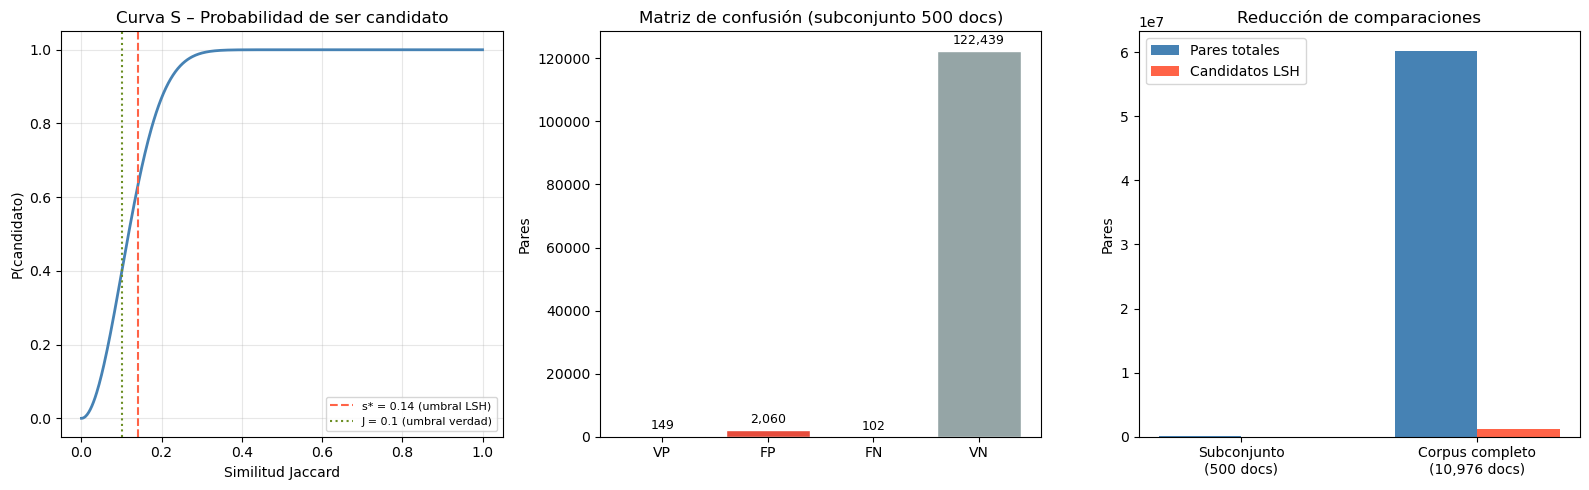

Precisión : 0.0675  |  Recall: 0.5936  |  F1: 0.1211
Reducción subconjunto  : 98.2%
Reducción corpus total : 98.0%


In [73]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sim_range = np.linspace(0, 1, 500)
prob      = 1 - (1 - sim_range**ROWS_PER_BAND)**N_BANDS
ax = axes[0]
ax.plot(sim_range, prob, color='steelblue', linewidth=2)
ax.axvline(s_star,          color='tomato',    linestyle='--', label=f's* = {s_star:.2f} (umbral LSH)')
ax.axvline(UMBRAL_JACCARD,  color='olivedrab', linestyle=':',  label=f'J = {UMBRAL_JACCARD} (umbral verdad)')
ax.set_title('Curva S – Probabilidad de ser candidato')
ax.set_xlabel('Similitud Jaccard')
ax.set_ylabel('P(candidato)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax = axes[1]
etiquetas_conf = ['VP', 'FP', 'FN', 'VN']
valores_conf   = [VP, FP, FN, VN]
colores_conf   = ['#2ecc71', '#e74c3c', '#e67e22', '#95a5a6']
bars = ax.bar(etiquetas_conf, valores_conf, color=colores_conf, edgecolor='white')
for bar, val in zip(bars, valores_conf):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(valores_conf)*0.01,
            f'{val:,}', ha='center', va='bottom', fontsize=9)
ax.set_title(f'Matriz de confusión (subconjunto {N_SUBSET} docs)')
ax.set_ylabel('Pares')
ax = axes[2]
labels_red = [f'Subconjunto\n({N_SUBSET} docs)', f'Corpus completo\n({len(conteodocs):,} docs)']
pares_totales  = [total_pares,    total_completo]
pares_cand     = [len(candidatos_subset), len(candidatos_completo)]
x, w = range(2), 0.35
ax.bar([i - w/2 for i in x], pares_totales, w, label='Pares totales',    color='steelblue')
ax.bar([i + w/2 for i in x], pares_cand,    w, label='Candidatos LSH',   color='tomato')
ax.set_title('Reducción de comparaciones')
ax.set_xticks(list(x))
ax.set_xticklabels(labels_red)
ax.set_ylabel('Pares')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Precisión : {precision:.4f}  |  Recall: {recall:.4f}  |  F1: {f1:.4f}')
print(f'Reducción subconjunto  : {reduccion:.1%}')
print(f'Reducción corpus total : {reduccion_completo:.1%}')

## 23. LSH Coseno – Proyección Aleatoria

Para similitud coseno se usan **hiperplanos aleatorios**: cada función hash asigna 1
si el vector proyecta a la mitad positiva del hiperplano, y 0 si cae en la negativa.

La propiedad clave es:

$$P\bigl(h(x) = h(y)\bigr) = 1 - \frac{\theta_{x,y}}{\pi}$$

donde $\theta_{x,y}$ es el ángulo entre $x$ e $y$. A mayor similitud coseno, mayor
probabilidad de colisión. Se opera sobre los vectores TF-IDF del subconjunto.

In [77]:
rng_otros = np.random.default_rng(42)
hiperplanos = rng_otros.standard_normal((N_HASH, len(vocab_idx))).astype(np.float32)
norms_h     = np.linalg.norm(hiperplanos, axis=1, keepdims=True)
hiperplanos = hiperplanos / norms_h  
tfidf_sub      = tfidf_matrix[:N_SUBSET]          
proyec_cos     = tfidf_sub @ hiperplanos.T         
firmas_coseno  = (proyec_cos >= 0).astype(np.int32) 
tablas_coseno     = construir_tablas_lsh(firmas_coseno, N_BANDS, ROWS_PER_BAND)
candidatos_coseno = extraer_candidatos(tablas_coseno)
reduccion_cos = 1 - len(candidatos_coseno) / total_pares
print(f'  Pares candidatos : {len(candidatos_coseno):,}')
print(f'  Reducción        : {reduccion_cos:.1%}')

  Pares candidatos : 124,750
  Reducción        : 0.0%


## 24. LSH Euclidiana – E2LSH

Para distancia euclidiana se usa **E2LSH**: se proyecta cada vector sobre una línea aleatoria
y se cuantiza el resultado en cubetas de ancho $w$:

$$h(x) = \left\lfloor \frac{a \cdot x + b}{w} \right\rfloor$$

donde $a \sim \mathcal{N}(0,1)$ es la dirección aleatoria y $b \sim U[0, w]$ es un desplazamiento.
Dos documentos caen en la misma cubeta cuando su proyección difiere en menos de $w$.

Las proyecciones se estandarizan antes de cuantizar para hacer $w$ interpretable
como fracción de la desviación estándar de las distancias del corpus.

In [80]:
W_EUCL = 0.5  
proyec_eu = rng_otros.standard_normal((N_HASH, len(vocab_idx))).astype(np.float32)
dots_eu   = tfidf_sub @ proyec_eu.T    
mu_eu     = dots_eu.mean(axis=0)
std_eu    = dots_eu.std(axis=0) + 1e-8
dots_eu_z = (dots_eu - mu_eu) / std_eu
firmas_eucl = np.floor(dots_eu_z / W_EUCL).astype(np.int32)
tablas_eucl     = construir_tablas_lsh(firmas_eucl, N_BANDS, ROWS_PER_BAND)
candidatos_eucl = extraer_candidatos(tablas_eucl)
reduccion_eu = 1 - len(candidatos_eucl) / total_pares
print(f'  Pares candidatos : {len(candidatos_eucl):,}')
print(f'  Reducción        : {reduccion_eu:.1%}')

  Pares candidatos : 118,147
  Reducción        : 5.3%


## 25. LSH Hamming – Muestreo de Bits

Para distancia Hamming se usa **muestreo aleatorio de bits**: dado un vector binario
(presencia o ausencia de cada término), se muestrea un subconjunto de $n$ posiciones.

$$h(x) = (x_{i_1},\, x_{i_2},\, \ldots,\, x_{i_n})$$

donde $\{i_1, \ldots, i_n\}$ son posiciones elegidas al azar.
La probabilidad de colisión en un bit es $1 - d_H(x, y) / |V|$,
donde $d_H$ es la distancia Hamming y $|V|$ es el tamaño del vocabulario.

La representación binaria indica si cada término del vocabulario aparece en el documento.

In [82]:
binario_sub = (tfidf_sub > 0).astype(np.int32)   
bit_pos       = rng_otros.choice(len(vocab_idx), size=N_HASH, replace=False)
firmas_hamming = binario_sub[:, bit_pos]            # (N_SUBSET, N_HASH)
tablas_hamming     = construir_tablas_lsh(firmas_hamming, N_BANDS, ROWS_PER_BAND)
candidatos_hamming = extraer_candidatos(tablas_hamming)
reduccion_ham = 1 - len(candidatos_hamming) / total_pares
print(f'  Pares candidatos : {len(candidatos_hamming):,}')
print(f'  Reducción        : {reduccion_ham:.1%}')

  Pares candidatos : 124,750
  Reducción        : 0.0%


## 26. Tabla Comparativa de Métodos (Paso 30)

Se calcula el número de pares candidatos que revisa cada método sobre el subconjunto
de **500 documentos** (total posible = 124 750 pares).

Para el **índice inverso** se cuentan todos los pares del subconjunto que comparten
al menos un término del vocabulario: son los pares que el índice inverso consideraría
candidatos en una búsqueda exhaustiva de todos contra todos.

In [84]:
pares_ii_subset = set()
for i in range(N_SUBSET):
    for p, _ in subset_bolsas[i]:
        for j_doc in indice_inverso.get(p, []):
            if j_doc < N_SUBSET and j_doc > i:
                pares_ii_subset.add((i, j_doc))
red_ii = 1 - len(pares_ii_subset) / total_pares
print(f'Pares revisados por índice inverso: {len(pares_ii_subset):,} ({1-red_ii:.1%} del total)')

Pares revisados por índice inverso: 47,989 (38.5% del total)


In [86]:
metodos_tabla = [
    ('Fuerza bruta',    'Exacto',      total_pares,              0.0),
    ('Índice inverso',  'Filtrado',    len(pares_ii_subset),     red_ii),
    ('LSH Jaccard',     'Aproximado',  len(candidatos_subset),   1 - len(candidatos_subset)/total_pares),
    ('LSH Coseno',      'Aproximado',  len(candidatos_coseno),   reduccion_cos),
    ('LSH Euclidiana',  'Aproximado',  len(candidatos_eucl),     reduccion_eu),
    ('LSH Hamming',     'Aproximado',  len(candidatos_hamming),  reduccion_ham),
]
print(f'{"Método":<18} {"Tipo":<12} {"Candidatos":>12} {"Reducción":>10}')
for nombre, tipo, cands, red in metodos_tabla:
    print(f'{nombre:<18} {tipo:<12} {cands:>12,} {red:>10.1%}')

Método             Tipo           Candidatos  Reducción
Fuerza bruta       Exacto            124,750       0.0%
Índice inverso     Filtrado           47,989      61.5%
LSH Jaccard        Aproximado          2,209      98.2%
LSH Coseno         Aproximado        124,750       0.0%
LSH Euclidiana     Aproximado        118,147       5.3%
LSH Hamming        Aproximado        124,750       0.0%


## 27. Visualización Final – Comparación de Métodos (Paso 31)

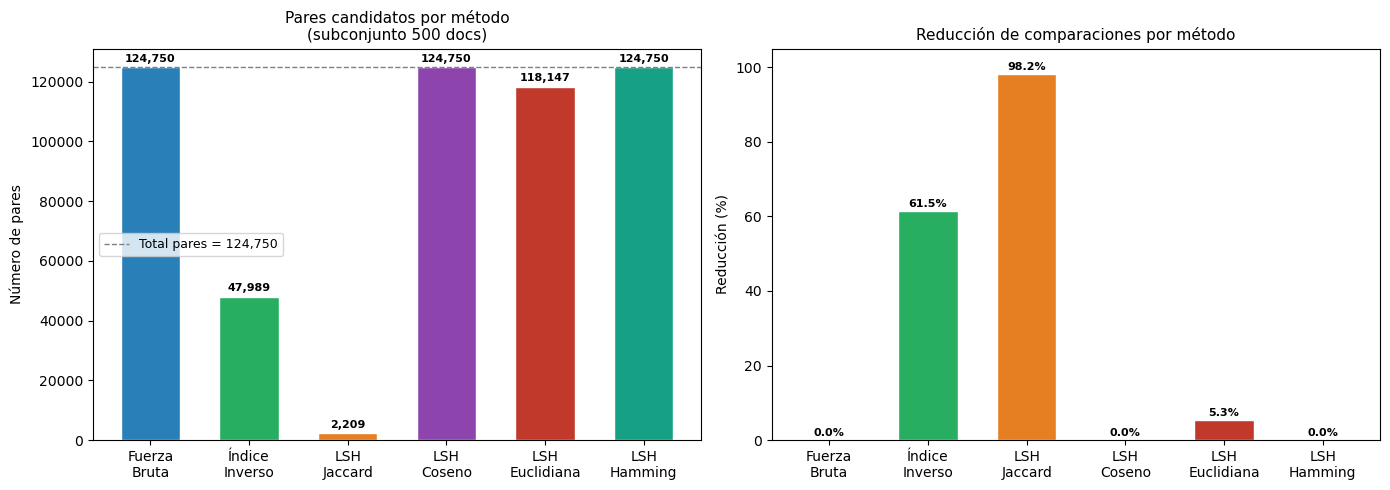

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
nombres = [
    'Fuerza\nBruta', 'Índice\nInverso',
    'LSH\nJaccard', 'LSH\nCoseno', 'LSH\nEuclidiana', 'LSH\nHamming'
]
n_cands = [
    total_pares,
    len(pares_ii_subset),
    len(candidatos_subset),
    len(candidatos_coseno),
    len(candidatos_eucl),
    len(candidatos_hamming),
]
colores = ['#2980b9', '#27ae60', '#e67e22', '#8e44ad', '#c0392b', '#16a085']
ax = axes[0]
bars = ax.bar(nombres, n_cands, color=colores, edgecolor='white', width=0.6)
for bar, val in zip(bars, n_cands):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + total_pares * 0.01,
            f'{val:,}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.axhline(total_pares, color='gray', linestyle='--', linewidth=1,
           label=f'Total pares = {total_pares:,}')
ax.set_title(f'Pares candidatos por método\n(subconjunto {N_SUBSET} docs)', fontsize=11)
ax.set_ylabel('Número de pares')
ax.legend(fontsize=9)
reducciones = [1 - c / total_pares for c in n_cands]
ax = axes[1]
bars = ax.bar(nombres, [r * 100 for r in reducciones], color=colores, edgecolor='white', width=0.6)
for bar, val in zip(bars, reducciones):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1%}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_title('Reducción de comparaciones por método', fontsize=11)
ax.set_ylabel('Reducción (%)')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()